# Explore here

In [2]:
import pandas as pd

# URL 
URL = "https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv"

def load_data(path):
    try:
        # Carga del dataset
        df = pd.read_csv(path)
        return df
    except Exception as e:
        print(f"Fallo en la extracción: {e}")
        return None

# Ejecución
df = load_data(URL)

if df is not None:
    print("Dataset cargado.")
    print(f"Dimensiones: {df.shape}")
    print(df.head())

Dataset cargado.
Dimensiones: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Bad pipe message: %s [b'\xed\x00\xe5\xa2\x13<s\xd4%\xa2+lJ\x1e\x06\xf0\xec\xba\x00\x00\x80\x00\x1d\x00\x1c\xfe\xff\xfe\xfe']
Bad pipe message: %s [b'\xfb\x92']
Bad pipe message: %s [b'\x1d1\x8dZ\xb8l\x05\xca\xb7\x94?_\xcd\x9b\xbdl"\x8c\x00\x00\x80\x00', b'\x15\xc0\x16\x00X\x00O\x00R\x00Q\x00P\x00S\x00V\x00U\x00T\x00\x81\x00\x83\x00\x80\x00\x82\x00)\x00&\x00*\x00\'\x00+\x00(\x00#\x00\x1f\x00"\x00\x1e\x00%\x00!\x00$\x00 \x00\x00\xc0\xaa\xc0\xab\x00\x8b\x00\x8c\x00\xae\xc0\xa4\xc0\xa8\x00\xa8\x00\x8d\x00\xaf\xc0\xa5\xc0\xa9\x00\xa9\xc0d\xc0']
Bad pipe message: %s [b'\r\xed\xd4\x07\x08\xfd\x8eE\xdd\x1dj\x94\xcb{>\x1f\xfd\x89\x00\x00z\x00\x93\x00\x94\x00\xb6\x00\xac\x00\x95\x00\xb7\x00\xad\xc0h\xc0n\xc0i\xc0o\xc0\x98\xc0\x92\xc0\x99\xc0\x93\xcc\xae\x00.\x00\xb8\x00\xb9\x00\x92\x00|\x00\n\x00', b'/\x00<\xc0\x9c\xc0\xa0\x00\x9c\x00~\x005\x00=\xc0\x9d\xc0\xa1\x00\x9d\xc0<\xc0P\xc0=\xc0Q\x00A\x00\xba\xc0z\x00\x84\x00\xc0\xc0{\x00\t\x00\x07\x00\x01\x00\x02\x00;\x00\x04\x00\x05\x00\x96\xc0\x1c\xc

La data llegó completa: Cargamos 1,338 registros, lo mejor es que no hay huecos (0 nulos), así que no vamos a perder tiempo inventando datos que faltan.
 Tenemos columnas como smoker y sex que están en texto. La computadora no lee, solo calcula,
 el código es para predecir charges. Es una cifra de dinero, así que buscamos un número exacto (Regresión).
  El costo promedio engañoso porque hay unos pocos que pagan muchísimo y suben la media. Hay que mirar la mediana, para ver la realidad.


In [ ]:
# variables binarias 
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df['sex'] = df['sex'].map({'female': 0, 'male': 1})

#  creamos columnas nuevas
df = pd.get_dummies(df, columns=['region'], drop_first=True)

# Verificamos que todo sea numérico ahora
print(df.head())

   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061              True   
4   32    1  28.880         0       0   3866.85520              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


Binarización: Se convirtieron las variables smoker y sex a formato numérico (0 y 1).

In [4]:
from sklearn.model_selection import train_test_split

# 1. Separamos el objetivo (y) de las pistas (X)
X = df.drop('charges', axis=1)
y = df['charges']

# 2. Dividimos: 80% para estudiar y 20% para el examen final
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras para entrenar: {len(X_train)}")
print(f"Muestras para probar: {len(X_test)}")

Muestras para entrenar: 1070
Muestras para probar: 268


Separé la data: 1,070 para entrenar y 268 para test. Seed 42 fija.

In [5]:
from sklearn.linear_model import LinearRegression

# 1. Llamo al algoritmo
model = LinearRegression()

# 2. Entreno con el 80% (fit)
model.fit(X_train, y_train)

# 3. Examen: trato de adivinar el 20% (predict)
predictions = model.predict(X_test)

print("Entrenamiento listo.")

Entrenamiento listo.


In [6]:
from sklearn.metrics import r2_score

# Comparamos con lo que el modelo predijo 
score = r2_score(y_test, predictions)

print(f"Precisión del modelo (R2): {score:.4f}")

Precisión del modelo (R2): 0.7836


El modelo pegó un 78.36% esto significa que casi el 80% de los costos están bien explicados por las variables que usamos.

In [7]:
# Ver el peso de cada variable
variables = X.columns
coeficientes = model.coef_

# Mostrar qué influye 
for var, coef in zip(variables, coeficientes):
    print(f"{var}: {coef:.2f}")

# 3. El punto de partida 
print(f"Base del costo (intercepto): {model.intercept_:.2f}")

age: 256.98
sex: -18.59
bmi: 337.09
children: 425.28
smoker: 23651.13
region_northwest: -370.68
region_southeast: -657.86
region_southwest: -809.80
Base del costo (intercepto): -11931.22


Impacto Dominante: Fumar dispara el costo en $23,651. Es la variable con más peso.

Edad y BMI: Cada año suma $256 y cada punto de masa corporal suma $337.

Geografía: Las regiones influyen poco, con descuentos de entre $370 y $809.

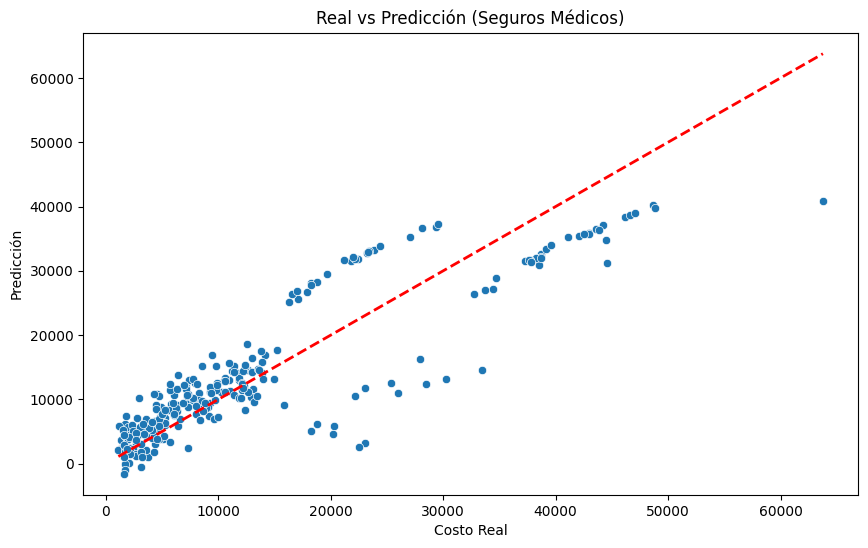

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos la gráfica de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions)

# Dibujamos la línea de perfección (donde real = predicción)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)

plt.xlabel('Costo Real')
plt.ylabel('Predicción')
plt.title('Real vs Predicción (Seguros Médicos)')
plt.show()

Precisión en Rangos Bajos: El modelo es muy preciso para costos menores a $15,000.

Dispersión en Rangos Altos: Existen tres grupos de datos. El modelo subestima los costos más elevados, lo que indica que una línea recta no es suficiente para captar la complejidad de los datos (especialmente el impacto de ser fumador)

In [9]:
from sklearn.ensemble import RandomForestRegressor

# 1. Cambiamos el algoritmo a uno más potente
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Entrenamos igual que antes
rf_model.fit(X_train, y_train)

# 3. Predicción y nuevo Score
rf_preds = rf_model.predict(X_test)
new_score = r2_score(y_test, rf_preds)

print(f"Nueva Precisión con Random Forest (R2): {new_score:.4f}")

Nueva Precisión con Random Forest (R2): 0.8650


Mejora de Precisión: El modelo Random Forest superó a la Regresión Lineal alcanzando un 86.50% de R2.

In [10]:
import joblib

# Guardamos el modelo en un archivo físico
joblib.dump(rf_model, 'modelo_seguros_rf.pkl')

print("Modelo guardado exitosamente como 'modelo_seguros_rf.pkl'")

Modelo guardado exitosamente como 'modelo_seguros_rf.pkl'


In [11]:
import joblib
import pandas as pd

# 1. Cargamos el modelo guardado
loaded_model = joblib.load('modelo_seguros_rf.pkl')

# 2. Creamos un cliente nuevo (Ejemplo: 30 años, fumador, BMI 25, 1 hijo, region_southwest)
# Nota: Debes mantener el mismo orden de columnas que en X_train
nuevo_cliente = pd.DataFrame([[30, 1, 25.0, 1, 1, 0, 0, 1]], 
                              columns=X.columns)

# 3. Predecimos el costo
prediccion = loaded_model.predict(nuevo_cliente)

print(f"El costo estimado del seguro para este cliente es: ${prediccion[0]:.2f}")

El costo estimado del seguro para este cliente es: $18664.89


Carga del Modelo: Se restauró exitosamente el archivo modelo_seguros_rf.pkl.

Resultado de Prueba: Para un perfil de 30 años y fumador, el sistema estimó un costo de $18,664.89.

Validación: El monto es coherente con el análisis de coeficientes, donde el tabaquismo es el factor determinante del precio.